In [1]:
import pathlib

from dotenv import load_dotenv

from config import STORE_DIR
from indexing.data_chunker import DataChunker, print_chunk_length_stats
from indexing.resumable_indexer import run_resumable_indexing
from llm_client import LLMClient
from indexing.vector_store import VectorStore

load_dotenv()

True

In [2]:
from config import EXTRACTED_MEDIA_DIR, STORE_DIR

data_path = pathlib.Path().cwd() / "data"
disruption_plans_path = data_path / "disruption_plans"
print(pathlib.Path().cwd())
print(f"Store: {STORE_DIR.resolve()}")

/Users/becca/Coursework/sem2/ai/cw2/Advanced-AI-Coursework-II
Store: /Users/becca/Coursework/sem2/ai/cw2/Advanced-AI-Coursework-II/.store


In [3]:
vector_store = VectorStore()

In [4]:
print(f"Collection has {vector_store.count()} existing documents")

Collection has 0 existing documents


In [5]:
llm_client = LLMClient()
chunker = DataChunker(llm_client)

DataChunker ready (store: /Users/becca/Coursework/sem2/ai/cw2/Advanced-AI-Coursework-II/.store)
  extracted_media: /Users/becca/Coursework/sem2/ai/cw2/Advanced-AI-Coursework-II/.store/extracted_media
  image cache: /Users/becca/Coursework/sem2/ai/cw2/Advanced-AI-Coursework-II/.store/image_descriptions_cache.json


In [6]:
all_paths = list((disruption_plans_path/"SWR Station Disruption Plans").rglob("*/**"))
# only files not directories
all_paths = [path for path in all_paths if path.is_file()]
# where path is doc, docx or pptx
all_paths = [path for path in all_paths if path.suffix in [".doc", ".docx", ".pptx", ".pptm"]]
for path in all_paths:
    print(path)


/Users/becca/Coursework/sem2/ai/cw2/Advanced-AI-Coursework-II/data/disruption_plans/SWR Station Disruption Plans/RM Central/Station Disruption Plan - Hampton Wick  Issue 1 - April 2018.docx
/Users/becca/Coursework/sem2/ai/cw2/Advanced-AI-Coursework-II/data/disruption_plans/SWR Station Disruption Plans/RM Central/Station Disruption Plan - Brookwood Issue 1 - April 2018.docx
/Users/becca/Coursework/sem2/ai/cw2/Advanced-AI-Coursework-II/data/disruption_plans/SWR Station Disruption Plans/RM Central/Station Disruption Plan - Worplesdon Issue 1 - April 2018.docx
/Users/becca/Coursework/sem2/ai/cw2/Advanced-AI-Coursework-II/data/disruption_plans/SWR Station Disruption Plans/RM Central/Station Disruption Plan - Tolworth  Issue 1 - April 2018.docx
/Users/becca/Coursework/sem2/ai/cw2/Advanced-AI-Coursework-II/data/disruption_plans/SWR Station Disruption Plans/RM Central/Station Disruption Plan - West Byfleet Issue 1 - April 2018.docx
/Users/becca/Coursework/sem2/ai/cw2/Advanced-AI-Coursework-II/

In [7]:
# chunk_paths = [
#     "RM Central/Station Disruption Plan - Aldershot Issue 1 - April 2018.docx",
#     "RM Waterloo/Station Disruption Plan Waterloo - Issue 1.doc",
#     "RM West/Station Disruption Plan - Weymouth Issue 1 - April 2018.docx"
# ]

In [22]:
chunk_paths = all_paths
# chunk_paths = all_paths[:30]

In [23]:
checkpoint_path = STORE_DIR / "indexing_checkpoint.json"
summary = run_resumable_indexing(
    paths=chunk_paths,
    chunker=chunker,
    vector_store=vector_store,
    checkpoint_path=checkpoint_path,
    max_workers=4,
    retry_failed=False,
)
print("\n--- Resumable indexing summary ---")
print(summary)
print(f"Collection total: {vector_store.count()} documents")
print(f"Checkpoint: {checkpoint_path}")


Starting resumable indexing with 4 worker(s) over 165 file(s).
Chunking: Station Disruption Plan - Alton Issue 1 - April 2018.docx
  Station: Alton
  Step 1/3: Reading document...
Chunking: Station Disruption Plan - New Malden  Issue 1 - April 2018.docx
  Station: New Malden
  Step 1/3: Reading document...
Chunking: Station Disruption Plan - Berrylands Issue 1 - April 2018.docx
  Station: Berrylands
  Step 1/3: Reading document...
Chunking: Station Disruption Plan - Bentley Issue 1 - April 2018.docx
  Station: Bentley
  Step 1/3: Reading document...
  Step 2/3: Describing slides / images (cache / LLM)...
  Cache hit: image2.jpeg (New Malden)
  Cache hit: image3.png (COMMUNICATION WITH CONTROL)
  Cache hit: image4.png (PRACTICAL OPERATION OF THE STATION)
  Found 3 image(s)
  Step 3/3: Splitting into section chunks...
  Done: 28 text + 3 image/guide = 31 total
  Station Disruption Plan - New Malden  Issue 1 - April 2018.docx: 31 chunks | min=12 max=3087 mean=696 chars
  text:  min=12 max

magick: delegate failed `'libreoffice' --convert-to pdf --outdir `dirname '%i'` '%i' 2> '%u'; /bin/mv '%i.pdf' '%o'' @ error/delegate.c/InvokeDelegate/1920.
magick: unable to open file '/var/folders/99/4gq0zyh135962s_jrf5fqj200000gp/T/magick-ZZ7SoIBeBhgMvc6PGk_zlwZRAR275HSZ': No such file or directory @ error/constitute.c/ReadImage/793.. Install: brew install libemf2svg librsvg


  Found 3 image(s)
  Step 3/3: Splitting into section chunks...
  Done: 28 text + 3 image/guide = 31 total
  Station Disruption Plan - Dorchester South Issue 1 - April.docx: 31 chunks | min=26 max=3087 mean=756 chars
  text:  min=26 max=3087 mean=771
  image: min=456 max=884 mean=612
Chunking: Station Disruption Plan - Andover  Issue 2 - January 2021.docx
  Station: Andover
  Step 1/3: Reading document...
VectorStore: upserting 31 chunks (28 text, 3 image) → 'disruption_plans'
  Step 2/3: Describing slides / images (cache / LLM)...
  LLM describing: image2.jpg (ROMSEY, Romsey SO51 8DU)
  LLM describing: image3.png (COMMUNICATION WITH CONTROL)
VectorStore: collection now has 4284 documents
[108/165] DONE Station Disruption Plan - Dorchester South Issue 1 - April.docx (31 chunks)
  Step 2/3: Describing slides / images (cache / LLM)...
  LLM describing: image2.jpg (Andover, Station Approach, Andover SP10 3HN)
  LLM describing: image3.png (COMMUNICATION WITH CONTROL)
  LLM describing: imag

In [ ]:
from pathlib import Path

target = disruption_plans_path / "SWR Station Disruption Plans" / "RM West/Station Disruption Plan - Worplesdon Issue 1 - April 2018.docx"
# swap target filename for Brookwood/Hampton Wick as needed

chunks = chunker.chunk_file(target)
max_len = max(len(c["text"]) for c in chunks)
print("max_len:", max_len)

for i, c in enumerate(chunks):
    n = len(c["text"])
    if n == max_len:
        m = c.get("metadata", {})
        print(f"\nChunk #{i} length={n}")
        print("section:", m.get("section"))
        print("type:", m.get("type"))
        print("source:", m.get("source"))
        print("station:", m.get("station"))
        print(c["text"][:700])

In [ ]:
for path in chunk_paths:
    chunks = chunker.chunk_file(path)
    for i, c in enumerate(chunks):
        if len(c["text"]) == 3969:
            m = c.get("metadata", {})
            print(path, "|", i, "|", m.get("section"), "|", m.get("type"))

In [ ]:
# first_data_path = (
#     disruption_plans_path
#     / "SWR Station Disruption Plans/RM Central/Station Disruption Plan - Aldershot Issue 1 - April 2018.docx"
# )

# print("--- Chunking ---")
# chunks = chunker.chunk_file(first_data_path)

# print("\n--- Indexing into Chroma ---")
# n = vector_store.add_chunks(chunks)

# print(f"\nSummary: {n} chunks indexed from {first_data_path.name}")
# print(f"Collection total: {vector_store.count()} documents")

# extracted_files = [p for p in EXTRACTED_MEDIA_DIR.rglob("*") if p.is_file()]
# print(f"Files in .store/extracted_media: {len(extracted_files)}")
# for p in sorted(extracted_files):
#     print(f"  {p.relative_to(STORE_DIR)}")

In [ ]:
# data/disruption_plans/SWR Station Disruption Plans/

In [ ]:
# first_data_path = (
#     disruption_plans_path
#     / "20 Batch 2 LOR 2-4 CPT (19th May 21).pptm"
# )

# print("--- Chunking ---")
# chunks = chunker.chunk_file(first_data_path)

# print("\n--- Indexing into Chroma ---")
# n = vector_store.add_chunks(chunks)

# print(f"\nSummary: {n} chunks indexed from {first_data_path.name}")
# print(f"Collection total: {vector_store.count()} documents")

# extracted_files = [p for p in EXTRACTED_MEDIA_DIR.rglob("*") if p.is_file()]
# print(f"Files in .store/extracted_media: {len(extracted_files)}")
# for p in sorted(extracted_files):
#     print(f"  {p.relative_to(STORE_DIR)}")

In [21]:
from pathlib import Path
from IPython.display import Image, display

results = vector_store.query(
    query_texts=["train blockage incident in brookwood"],
    n_results=5,
)

for i, (doc, meta) in enumerate(zip(results["documents"][0], results["metadatas"][0])):
    print(f"--- Result {i+1} [{meta.get('station')} / {meta.get('section')}] ---")
    #print meta keys
    # print(meta.keys())
    # dict_keys(['filename', 'image_type', 'source_image', 'type', 'section', 'source', 'caption', 'slide_number', 'blocked_section', 'image_path', 'document_type', 'stations_or_junctions', 'station'])

    print(doc)
    # print(doc[:400])
    # doc_type = meta.get("type")
    # image_type = meta.get("image_type")
    # source_image = meta.get("source_image")
    # caption = meta.get("caption")
    # slide_number = meta.get("slide_number")
    # blocked_section = meta.get("blocked_section")
    # stations_or_junctions = meta.get("stations_or_junctions")
    # station = meta.get("station")
    # document_type = meta.get("document_type")
    # filename = meta.get("filename")
    # section = meta.get("section")
    # print(f"Document type: {doc_type}")
    # print(f"Image type: {image_type}")
    # print(f"Source image: {source_image}")
    # print(f"Caption: {caption}")
    # print(f"Slide number: {slide_number}")
    # print(f"Blocked section: {blocked_section}")
    # print(f"Stations or junctions: {stations_or_junctions}")
    # print(f"Station: {station}")
    # print(f"Document type: {document_type}")
    # print(f"Filename: {filename}")
    # print(f"Section: {section}")
    # image_path = meta.get("image_path")
    # if image_path and Path(image_path).exists():
    #     print(f"Image: {image_path}")
    #     display(Image(filename=image_path))
    
   
    print()

--- Result 1 [Brookwood / TOP TIPS FOR THIS STATION] ---
# TOP TIPS FOR THIS STATION

Issue: Flooding to the Brookwood subway.
Tip: Customers for Brookwood traveling from the up direction circulate via Farnborough Main.
Issue: Flooding to Brookwood subway.
Tip: Customers wishing to travel in the down direction circulate via Woking.

--- Result 2 [Cobham / TOP TIPS FOR THIS STATION] ---
# TOP TIPS FOR THIS STATION

Issue: No train services due to disruption
Tip: Customers advised to use bus/car to Weybridge, and also car to Leatherhead. Cabline should be used for customers requiring assistance during staffed hours. Cobham Cars (Taxis) could be considered if Cabline unable to provide taxis.

--- Result 3 [Bookham / USEFUL WEBSITES & TOOLS] ---
# USEFUL WEBSITES & TOOLS

If you are aware of issues with your train information on stations, please make your local SCP aware (if you have one) as they will be able to help by updating the screens as appropriate.

If you don’t have an SCP you sho

In [ ]:
chunked = chunker.chunk_directory(disruption_plans_path)
all_chunks = [chunk for chunks in chunked.values() for chunk in chunks]
n = vector_store.add_chunks(all_chunks)
print(f"\nIndexed {n} chunks across {len(chunked)} files")
print(f"Collection now has {vector_store.count()} documents")

--- Result 1 [Aldershot / PRACTICAL OPERATION OF THE STATION] ---
# PRACTICAL OPERATION OF THE STATION

[Image: aldershot-station-map.png] Map of Aldershot station showing zones and platform access. This image depicts an overview of Aldershot station, segmented into different zones: Welcome zone (dark blue), Ticket zone (light blue), Train zone (yellow), Onward travel (red), Night gate (purple), and Discretionary zone (grey). The diagram shows the station layout

--- Result 2 [Aldershot / Aldershot] ---
# Aldershot

--- Result 3 [Aldershot / PRACTICAL OPERATION OF THE STATION] ---
[Image: aldershot-station-map.png] Map of Aldershot station showing zones and platform access. This image depicts an overview of Aldershot station, segmented into different zones: Welcome zone (dark blue), Ticket zone (light blue), Train zone (yellow), Onward travel (red), Night gate (purple), and Discretionary zone (grey). The diagram shows the station layout with platforms 1, 2, and 3, along wit
Image: /Use

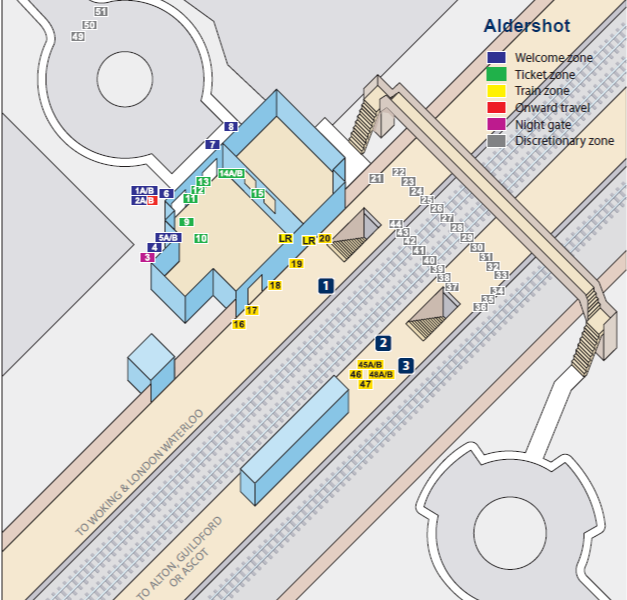


--- Result 4 [Bentley / TOP TIPS FOR THIS STATION] ---
# TOP TIPS FOR THIS STATION

Issue: Service disruption leading to no services through Bentley Station.
Tip: Advise passengers where possible to use Aldershot or Guildford stations for alternative services (requesting car park easements at both stations).

--- Result 5 [Guildford / SUPPORT FOR OTHER STATIONS] ---
## SUPPORT FOR OTHER STATIONS

Below is a list of stations that this station may be in a position to support during disruption.

Station Name — Haslemere: Wanborough
Telephone Number — 07876 578659 / 01483 465662: N/A
Times — 0600-2044 Mon to Fri. 0600-2000 Sat. 0800-1800 Sun: N/A
Station Name — Haslemere: Ash
Telephone Number — 07876 578659 / 01483 465662: 07920 156126 / 0067573
Times — 0600-2044



In [24]:
from pathlib import Path
from IPython.display import Image, display

results = vector_store.query(
    query_texts=["Aldershot station incident"],
    n_results=5,
)

for i, (doc, meta) in enumerate(zip(results["documents"][0], results["metadatas"][0])):
    print(f"--- Result {i+1} [{meta.get('station')} / {meta.get('section')}] ---")
    print(doc[:400])
    image_path = meta.get("image_path")
    if image_path and Path(image_path).exists():
        print(f"Image: {image_path}")
        display(Image(filename=image_path))
    print()